In [3]:
from __future__ import annotations

from ast import literal_eval
from collections import Counter
from datetime import datetime
from pathlib import Path
from typing import Dict, Iterable, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CSV_PATH = Path("/Users/yejoon/Documents/ai tech/tilda_data/news_articles_resources.csv")
CHUNK_SIZE = 20000
TOP_N = 20

# Columns we expect (safe to read a subset if needed)
COLUMNS = [
    "id",
    "title",
    "doc_url",
    "all_text",
    "authors",
    "publish_date",
    "meta_site_name",
    "key_word",
    "filter_status",
    "description",
    "named_entities",
    "triples",
    "article_embedding",
]


def safe_list(value: str) -> List[str]:
    if value is None:
        return []
    value = str(value).strip()
    if not value or value == "nan":
        return []
    try:
        parsed = literal_eval(value)
        if isinstance(parsed, list):
            return [str(x) for x in parsed]
    except Exception:
        return []
    return []


def iter_chunks(path: Path) -> Iterable[pd.DataFrame]:
    return pd.read_csv(path, chunksize=CHUNK_SIZE, usecols=COLUMNS)


# Aggregations
row_count = 0
missing_counts = Counter()
site_counts = Counter()
keyword_counts = Counter()
entity_counts = Counter()
monthly_counts = Counter()
filter_status_counts = Counter()

# Length distributions (for histograms)
text_len_bins = np.array([0, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000])
text_len_hist = np.zeros(len(text_len_bins) - 1, dtype=int)


desc_len_bins = np.array([0, 50, 100, 200, 400, 800, 1600, 3200, 6400])
desc_len_hist = np.zeros(len(desc_len_bins) - 1, dtype=int)


keyword_len_bins = np.array([0, 10, 20, 40, 80, 120, 200, 400])
keyword_len_hist = np.zeros(len(keyword_len_bins) - 1, dtype=int)


entity_len_bins = np.array([0, 1, 2, 3, 5, 10, 20, 40, 80, 160])
entity_len_hist = np.zeros(len(entity_len_bins) - 1, dtype=int)


for chunk in iter_chunks(CSV_PATH):
    row_count += len(chunk)

    # Missing values per column
    missing_counts.update(chunk.isna().sum().to_dict())

    # Site distribution
    if "meta_site_name" in chunk.columns:
        site_counts.update(chunk["meta_site_name"].dropna().astype(str))

    # Keyword distribution (exact key_word string)
    if "key_word" in chunk.columns:
        keyword_values = chunk["key_word"].dropna().astype(str)
        keyword_counts.update(keyword_values)
        lengths = keyword_values.str.len().values
        if len(lengths):
            hist, _ = np.histogram(lengths, bins=keyword_len_bins)
            keyword_len_hist += hist

    # Filter status distribution
    if "filter_status" in chunk.columns:
        filter_status_counts.update(chunk["filter_status"].dropna().astype(str))

    # Named entities distribution
    if "named_entities" in chunk.columns:
        for raw in chunk["named_entities"].dropna().astype(str):
            entities = safe_list(raw)
            entity_counts.update(entities)
            length = len(entities)
            hist, _ = np.histogram([length], bins=entity_len_bins)
            entity_len_hist += hist

    # Publish date distribution (monthly)
    if "publish_date" in chunk.columns:
        dt = pd.to_datetime(chunk["publish_date"], errors="coerce")
        month = dt.dt.to_period("M").astype(str)
        monthly_counts.update(month.dropna())

    # Text length distributions
    if "all_text" in chunk.columns:
        lengths = chunk["all_text"].dropna().astype(str).str.len().values
        if len(lengths):
            hist, _ = np.histogram(lengths, bins=text_len_bins)
            text_len_hist += hist

    if "description" in chunk.columns:
        lengths = chunk["description"].dropna().astype(str).str.len().values
        if len(lengths):
            hist, _ = np.histogram(lengths, bins=desc_len_bins)
            desc_len_hist += hist


print(f"Total rows: {row_count}")
print("Missing values per column (top 10):")
for col, count in missing_counts.most_common(10):
    print(f"  {col}: {count}")

print("\nTop sites:")
for name, count in site_counts.most_common(10):
    print(f"  {name}: {count}")

print("\nTop keywords:")
for name, count in keyword_counts.most_common(10):
    print(f"  {name}: {count}")

print("\nTop entities:")
for name, count in entity_counts.most_common(10):
    print(f"  {name}: {count}")

Total rows: 296514
Missing values per column (top 10):
  article_embedding: 193071
  authors: 34944
  description: 2292
  title: 81
  all_text: 67
  id: 0
  doc_url: 0
  publish_date: 0
  meta_site_name: 0
  key_word: 0

Top sites:
  Yahoo Entertainment: 19166
  Seeking Alpha: 8248
  ETF Daily News: 7073
  PRNewswire: 6968
  The Times of India: 6650
  Plos.org: 4678
  GlobeNewswire: 4529
  Forbes: 4499
  Marketscreener.com: 4058
  BusinessLine: 3139

Top keywords:
  rice and (price or demand or supply or inventory): 99611
  corn and (price or demand or supply or inventory): 80248
  wheat and (price or demand or supply or inventory): 52720
  united states department of agriculture: 44844
  soybean and (price or demand or supply or inventory): 10734
  national agricultural statistics service: 4638
  sorghum and (price or demand or supply or inventory): 1798
  "soybean oil" and (production or outputs or supplies or supply or biofuel or biodiesel or demand or price): 914
  "soybean product

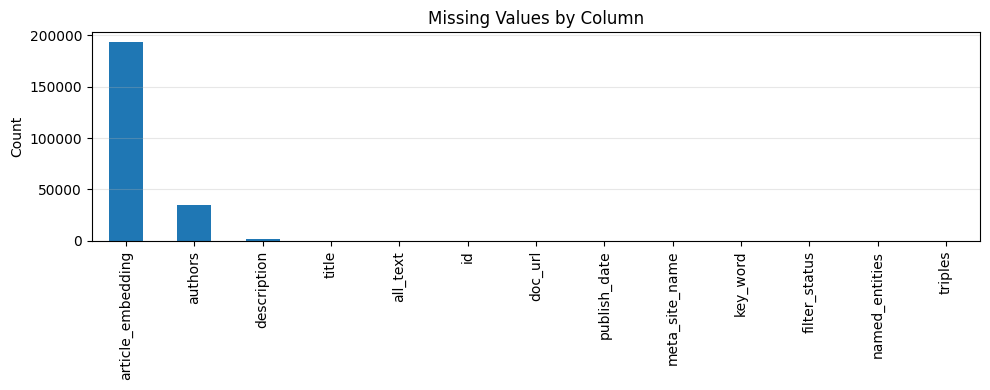

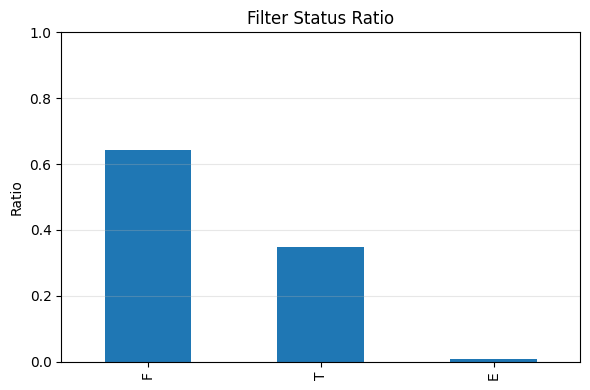

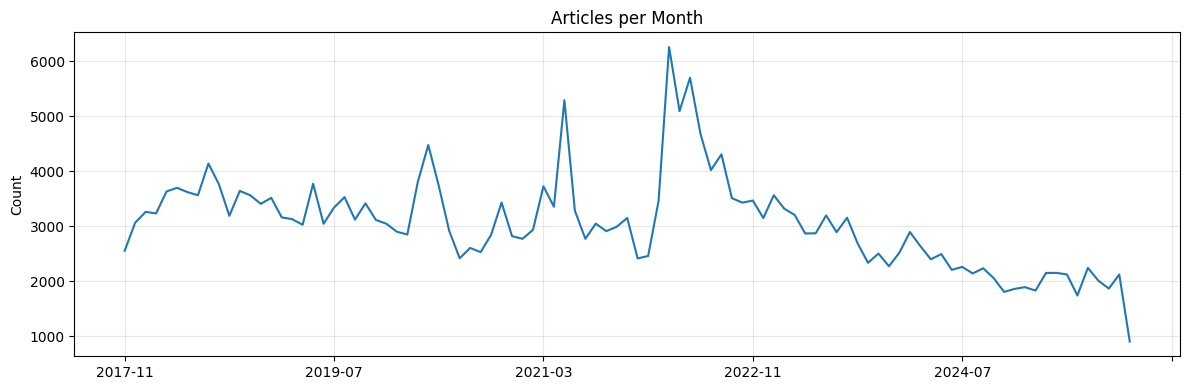

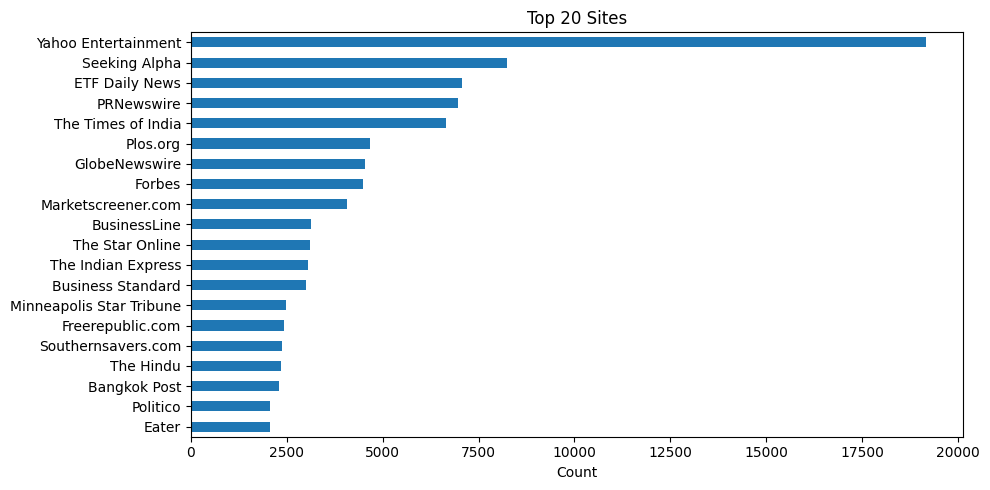

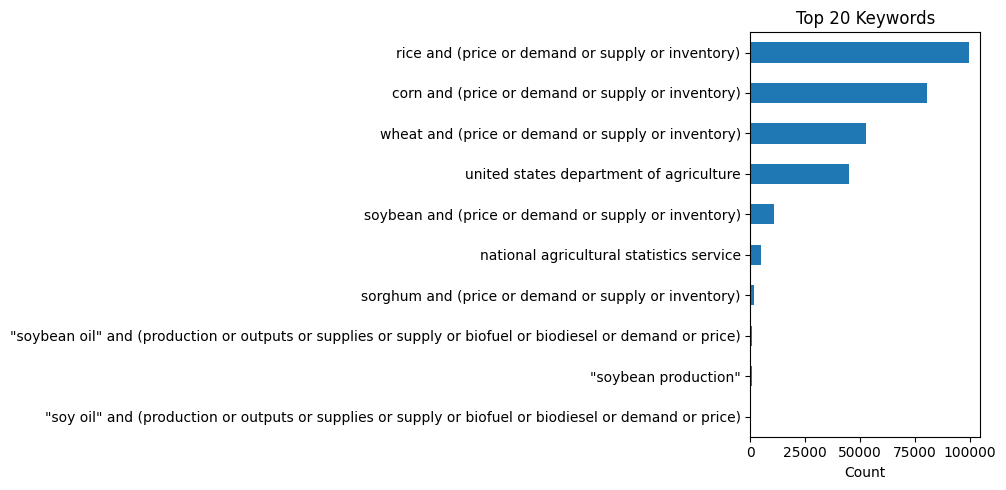

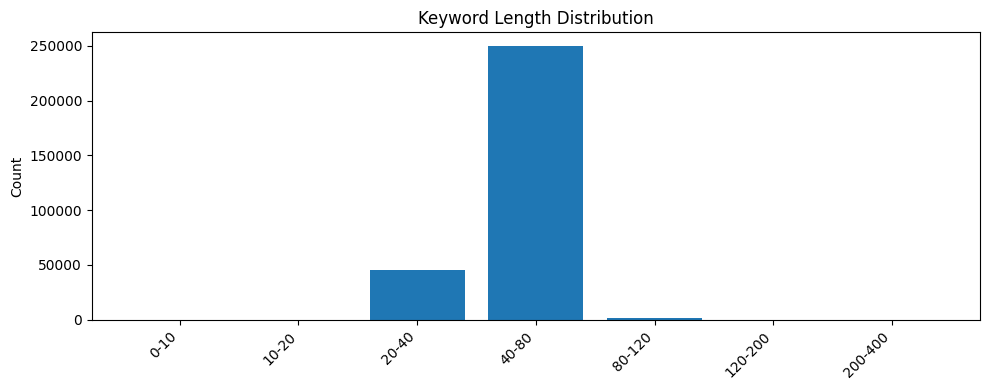

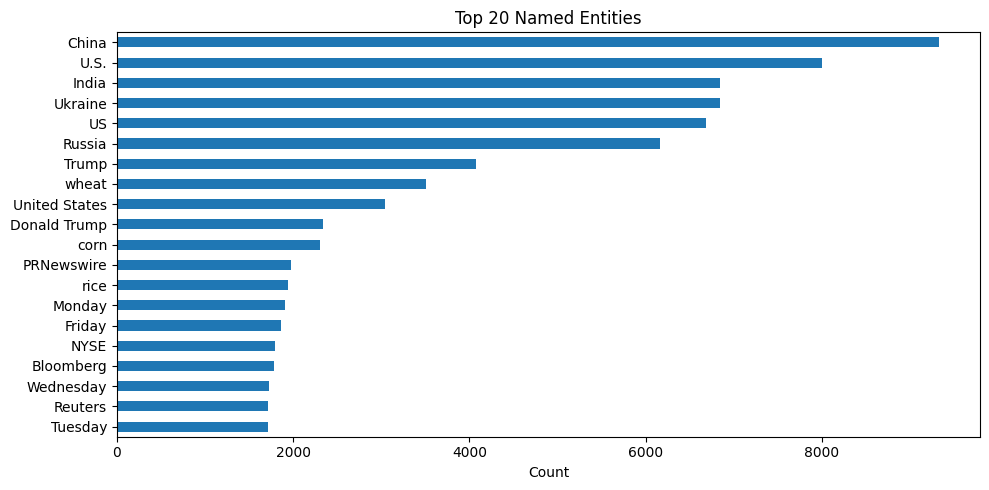

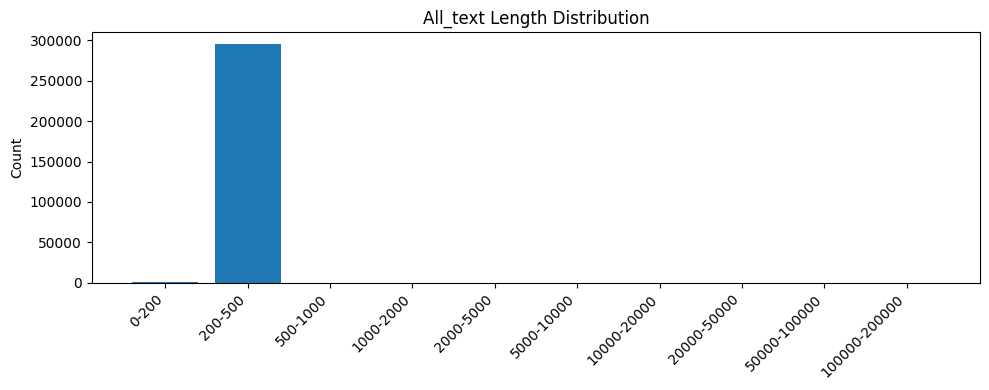

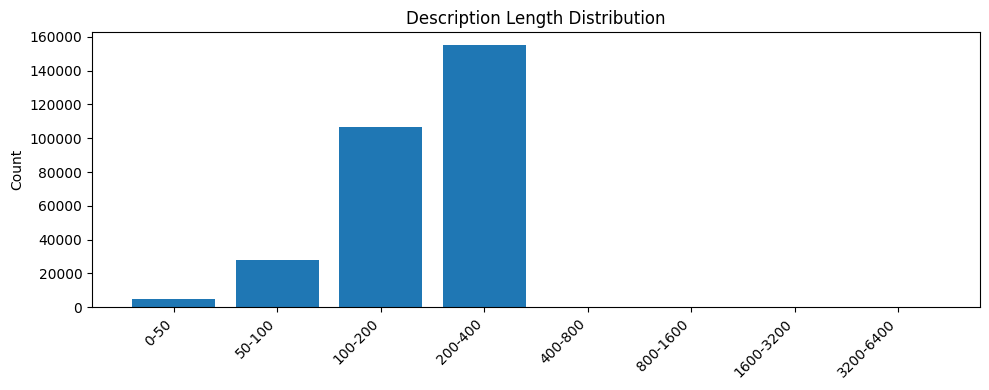

In [4]:
# Plot missing values
plt.figure(figsize=(10, 4))
missing_series = pd.Series(dict(missing_counts)).sort_values(ascending=False)
missing_series.plot(kind="bar")
plt.title("Missing Values by Column")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Filter status ratio
if filter_status_counts:
    status_series = pd.Series(dict(filter_status_counts))
    status_ratio = (status_series / status_series.sum()).sort_values(ascending=False)
    plt.figure(figsize=(6, 4))
    status_ratio.plot(kind="bar")
    plt.title("Filter Status Ratio")
    plt.ylabel("Ratio")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot articles per month
if monthly_counts:
    month_series = pd.Series(dict(monthly_counts)).sort_index()
    plt.figure(figsize=(12, 4))
    month_series.plot()
    plt.title("Articles per Month")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Top sites
if site_counts:
    top_sites = pd.Series(dict(site_counts.most_common(TOP_N)))
    plt.figure(figsize=(10, 5))
    top_sites.sort_values().plot(kind="barh")
    plt.title(f"Top {TOP_N} Sites")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

# Top keywords
if keyword_counts:
    top_keywords = pd.Series(dict(keyword_counts.most_common(TOP_N)))
    plt.figure(figsize=(10, 5))
    top_keywords.sort_values().plot(kind="barh")
    plt.title(f"Top {TOP_N} Keywords")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

# Keyword length distribution
plt.figure(figsize=(10, 4))
labels = [f"{keyword_len_bins[i]}-{keyword_len_bins[i+1]}" for i in range(len(keyword_len_bins)-1)]
plt.bar(labels, keyword_len_hist)
plt.title("Keyword Length Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Named entity list length distribution
plt.figure(figsize=(10, 4))
labels = [f"{entity_len_bins[i]}-{entity_len_bins[i+1]}" for i in range(len(entity_len_bins)-1)]
plt.bar(labels, entity_len_hist)
plt.title("Named Entity List Length Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Top named entities
if entity_counts:
    top_entities = pd.Series(dict(entity_counts.most_common(TOP_N)))
    plt.figure(figsize=(10, 5))
    top_entities.sort_values().plot(kind="barh")
    plt.title(f"Top {TOP_N} Named Entities")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

# Text length distribution
plt.figure(figsize=(10, 4))
labels = [f"{text_len_bins[i]}-{text_len_bins[i+1]}" for i in range(len(text_len_bins)-1)]
plt.bar(labels, text_len_hist)
plt.title("All_text Length Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Description length distribution
plt.figure(figsize=(10, 4))
labels = [f"{desc_len_bins[i]}-{desc_len_bins[i+1]}" for i in range(len(desc_len_bins)-1)]
plt.bar(labels, desc_len_hist)
plt.title("Description Length Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()